In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

100%|██████████████████████████████████████| 60.3M/60.3M [00:05<00:00, 12.3MB/s]

Extracting model files...


Path to dataset files: /home/mca/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [2]:
print("Dataset saved at:", path)


Dataset saved at: /home/mca/.cache/kagglehub/datasets/msambare/fer2013/versions/1


### Overview:

##### Your project integrates two deep learning models for facial analysis and music recommendation:

##### Mood Detection: A custom CNN trained on the FER2013 dataset to classify facial expressions into 7 emotion classes.

##### Age & Gender Estimation: A MobileNetV2-based transfer learning model trained on the UTKFace dataset to predict age (regression) and gender (binary classification).

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
# Paths
train_dir = "train"
test_dir = "test"
img_size = (48, 48)
batch_size = 64
# Data augmentation
train_datagen = ImageDataGenerator(
   rescale=1./255,
   rotation_range=30,
   width_shift_range=0.2,
   height_shift_range=0.2,
   shear_range=0.2,
   zoom_range=0.2,
   horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
   train_dir,
   target_size=img_size,
   color_mode="grayscale",
   batch_size=batch_size,
   class_mode="categorical",
   shuffle=True
)
test_generator = test_datagen.flow_from_directory(
   test_dir,
   target_size=img_size,
   color_mode="grayscale",
   batch_size=batch_size,
   class_mode="categorical",
   shuffle=False
)
# Improved CNN model
model = models.Sequential([
   layers.Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(48,48,1)),
   layers.BatchNormalization(),
   layers.Conv2D(64, (3,3), padding='same', activation='relu'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(2,2),
   layers.Dropout(0.25),
   layers.Conv2D(128, (3,3), padding='same', activation='relu'),
   layers.BatchNormalization(),
   layers.Conv2D(128, (3,3), padding='same', activation='relu'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(2,2),
   layers.Dropout(0.3),
   layers.Conv2D(256, (3,3), padding='same', activation='relu'),
   layers.BatchNormalization(),
   layers.Conv2D(256, (3,3), padding='same', activation='relu'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(2,2),
   layers.Dropout(0.35),
   layers.GlobalAveragePooling2D(),
   layers.Dense(512, activation='relu'),
   layers.BatchNormalization(),
   layers.Dropout(0.5),
   layers.Dense(7, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
             loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = [
   tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
   tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
]
history1 = model.fit(
   train_generator,
   validation_data=test_generator,
   epochs=40,
   callbacks=callbacks
)
model.save("fer2013_emotion_model_improved.h5")
print("✅ Model trained and saved as fer2013_emotion_model_improved.h5")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Epoch 1/40


2025-10-06 14:48:51.282670: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout_11/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


449/449 [==============================] - 16s 31ms/step - loss: 2.1947 - accuracy: 0.2087 - val_loss: 1.9056 - val_accuracy: 0.2080 - lr: 0.0010
Epoch 2/40
449/449 [==============================] - 14s 31ms/step - loss: 1.8036 - accuracy: 0.2906 - val_loss: 1.7939 - val_accuracy: 0.3001 - lr: 0.0010
Epoch 3/40
449/449 [==============================] - 14s 31ms/step - loss: 1.5624 - accuracy: 0.3968 - val_loss: 1.5099 - val_accuracy: 0.4277 - lr: 0.0010
Epoch 4/40
449/449 [==============================] - 14s 31ms/step - loss: 1.4199 - accuracy: 0.4549 - val_loss: 1.3894 - val_accuracy: 0.4870 - lr: 0.0010
Epoch 5/40
449/449 [==============================] - 14s 31ms/step - loss: 1.3259 - accuracy: 0.4940 - val_loss: 1.2518 - val_accuracy: 0.5333 - lr: 0.0010
Epoch 6/40
449/449 [==============================] - 14s 31ms/step - loss: 1.2744 - accuracy: 0.5159 - val_loss: 1.1899 - val_accuracy: 0.5513 - lr: 0.0010
Epoch 7/40
449/449 [==============================] - 14s 31ms/step -

/home/mca/anaconda3/envs/dse/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


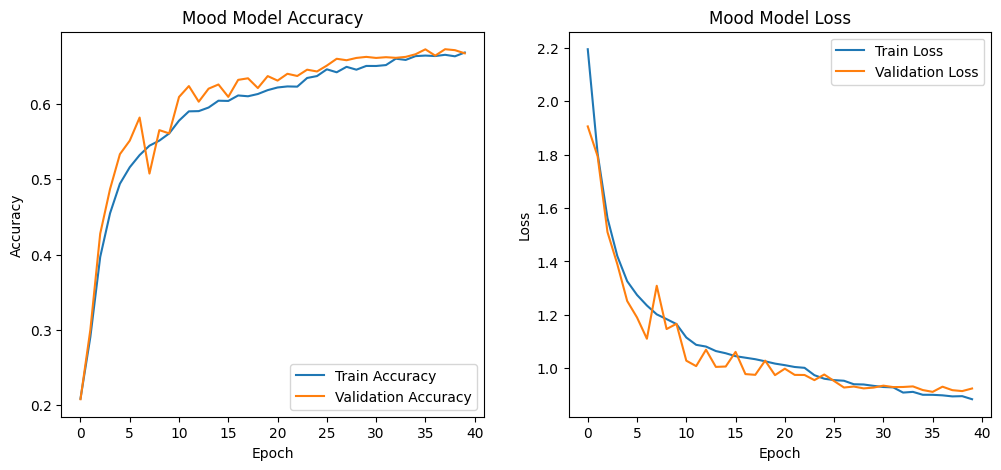

In [16]:
import matplotlib.pyplot as plt

def plot_mood_model_history(history):
    # Accuracy curves
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Mood Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss curves
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Mood Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Call this after training your mood model
plot_mood_model_history(history1)


In [8]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Paths
base_path = "/home/mca/230968306_Abhigya/DL Project"
possible_dirs = ["UTKFace_aligned_cropped", "crop_part1", "UTKFace"]

image_dir = None
for d in possible_dirs:
    full_path = os.path.join(base_path, d)
    if os.path.exists(full_path):
        files = [f for f in os.listdir(full_path) if f.endswith(".jpg")]
        if len(files) > 100:
            image_dir = full_path
            break

if image_dir is None:
    raise Exception("No valid dataset folder found.")

# Parameters
img_size = 224  # MobileNetV2 default input size
batch_size = 64

# Load data
images, ages, genders = [], [], []
for file in os.listdir(image_dir):
    if not file.endswith(".jpg"):
        continue
    parts = file.split("_")
    if len(parts) < 4:
        continue
    try:
        age = int(parts[0])
        gender = int(parts[1])
        img_path = os.path.join(image_dir, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img)
        ages.append(age)
        genders.append(gender)
    except Exception:
        continue

images = np.array(images)
ages = np.array(ages) / 100.0  # normalize age
genders = np.array(genders)

# Train-test split
X_train, X_test, age_train, age_test, gender_train, gender_test = train_test_split(
    images, ages, genders, test_size=0.2, random_state=42
)

# Data augmentation generator (on raw images)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

def data_generator(images, ages, genders, batch_size, datagen):
    length = len(images)
    indices = np.arange(length)
    while True:
        np.random.shuffle(indices)
        for i in range(0, length, batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_images = images[batch_indices]
            batch_ages = ages[batch_indices]
            batch_genders = genders[batch_indices]

            augmented_images = np.empty_like(batch_images)
            for j in range(len(batch_images)):
                augmented_images[j] = datagen.random_transform(batch_images[j])

            # Preprocess using MobileNetV2's preprocess_input
            augmented_images = preprocess_input(augmented_images.astype(np.float32))

            yield augmented_images, {'age_output': batch_ages, 'gender_output': batch_genders}

# Preprocess test data as well
X_test_processed = preprocess_input(X_test.astype(np.float32))

# Build model
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))

# Freeze all layers except last 20
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

age_output = Dense(1, activation='linear', name='age_output')(x)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(x)

model = Model(inputs=base_model.input, outputs=[age_output, gender_output])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={'age_output': tf.keras.losses.Huber(), 'gender_output': 'binary_crossentropy'},
    loss_weights={'age_output': 1.0, 'gender_output': 0.5},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy'}
)

model.summary()

steps_per_epoch = len(X_train) // batch_size

history = model.fit(
    data_generator(X_train, age_train, gender_train, batch_size, datagen),
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_test_processed, {'age_output': age_test, 'gender_output': gender_test}),
    epochs=20,
    verbose=1
)

model.save("age_gender_mobilenet_transfer_learning.h5")
print(" Model saved as 'age_gender_mobilenet_transfer_learning.h5'")


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_3[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

/home/mca/anaconda3/envs/dse/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [7]:
import numpy as np
unique, counts = np.unique(genders, return_counts=True)
print(dict(zip(unique, counts)))


{0: 4372, 1: 5406}


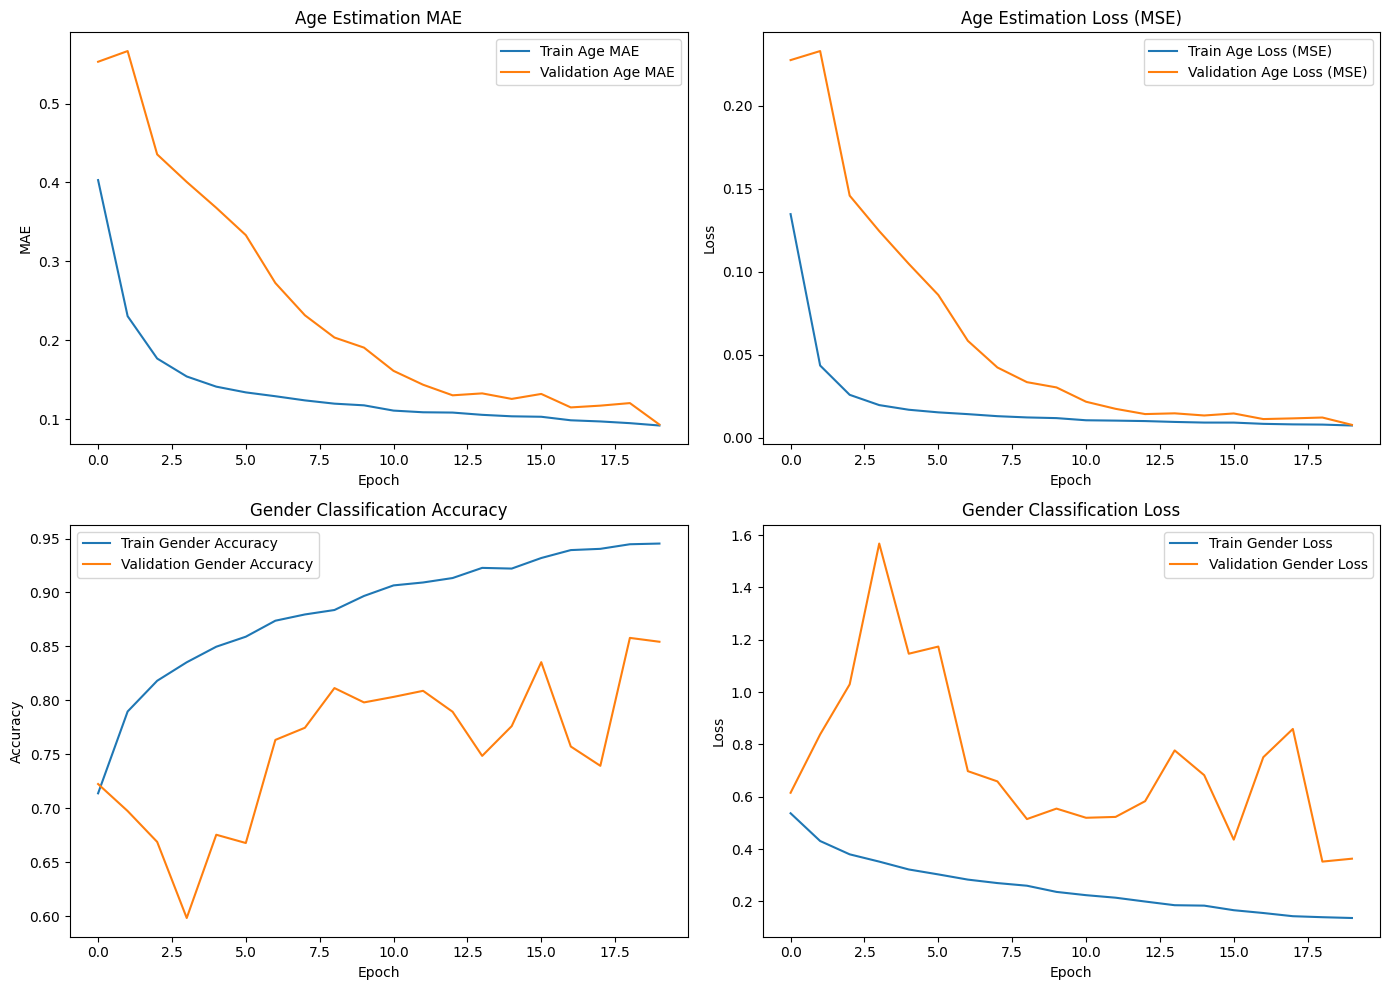

In [9]:
import matplotlib.pyplot as plt
def plot_age_gender_history(history):
    # Age - MAE (metric)
    plt.figure(figsize=(14,10))

    plt.subplot(2,2,1)
    plt.plot(history.history['age_output_mae'], label='Train Age MAE')
    plt.plot(history.history['val_age_output_mae'], label='Validation Age MAE')
    plt.title('Age Estimation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    # Age - Loss (MSE)
    plt.subplot(2,2,2)
    plt.plot(history.history['age_output_loss'], label='Train Age Loss (MSE)')
    plt.plot(history.history['val_age_output_loss'], label='Validation Age Loss (MSE)')
    plt.title('Age Estimation Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Gender - Accuracy
    plt.subplot(2,2,3)
    plt.plot(history.history['gender_output_accuracy'], label='Train Gender Accuracy')
    plt.plot(history.history['val_gender_output_accuracy'], label='Validation Gender Accuracy')
    plt.title('Gender Classification Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Gender - Loss (Binary Crossentropy)
    plt.subplot(2,2,4)
    plt.plot(history.history['gender_output_loss'], label='Train Gender Loss')
    plt.plot(history.history['val_gender_output_loss'], label='Validation Gender Loss')
    plt.title('Gender Classification Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call this after training your age/gender model
plot_age_gender_history(history)


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

100%|████████████████████████████████████████| 331M/331M [00:20<00:00, 16.9MB/s]

Extracting model files...


Path to dataset files: /home/mca/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


In [11]:
import cv2
import numpy as np
import tensorflow as tf
import os
import random
import pygame
from tensorflow.keras.models import load_model
from collections import deque
# === Models ===
mood_model = load_model("fer2013_emotion_model_improved.h5", compile=False)
age_gender_model = load_model("age_gender_mobilenet_transfer_learning.h5", compile=False)
mood_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
# === Helper Functions ===
def get_gender_label(pred):
   return "Male" if pred < 0.5 else "Female"
def get_age_group(age):
   if age < 18: return "teen"
   elif age < 40: return "adult"
   else: return "senior"
def play_song(mood, age_group):
   music_dir = os.path.join("music", mood.lower(), age_group)
   if not os.path.exists(music_dir):
       print(f"No folder for {mood}/{age_group}")
       return
   songs = [f for f in os.listdir(music_dir) if f.endswith(".mp3")]
   if not songs:
       print(f"No songs found for {mood}/{age_group}")
       return
   song_path = os.path.join(music_dir, random.choice(songs))
   print(f"🎵 Now playing: {song_path}")
   if not pygame.mixer.get_init():
       pygame.mixer.init()
   pygame.mixer.music.load(song_path)
   pygame.mixer.music.play()
# === Face Detection (OpenCV DNN, matching training crops) ===
prototxt = "models/deploy.prototxt"
weights = "models/res10_300x300_ssd_iter_140000.caffemodel"
face_net = cv2.dnn.readNetFromCaffe(prototxt, weights)
cap = cv2.VideoCapture(0)
mood_queue = deque(maxlen=15)
age_queue = deque(maxlen=15)
current_mood = None
current_age_group = None
while True:
   ret, frame = cap.read()
   if not ret:
       break
   h, w = frame.shape[:2]
   blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0,
                                (300, 300), (104.0, 177.0, 123.0))
   face_net.setInput(blob)
   detections = face_net.forward()
   for i in range(detections.shape[2]):
       confidence = detections[0, 0, i, 2]
       if confidence > 0.6:
           box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
           (x1, y1, x2, y2) = box.astype("int")
           x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w-1, x2), min(h-1, y2)
           face = frame[y1:y2, x1:x2]
           if face.size == 0:
               continue
           # Mood preprocessing (grayscale 48x48, rescale)
           face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
           face_gray = cv2.resize(face_gray, (48, 48)) / 255.0
           face_gray = np.expand_dims(face_gray, axis=(0, -1))
           # Age/Gender preprocessing (RGB 96x96, rescale)
           face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
           face_rgb = cv2.resize(face_rgb, (96, 96)) / 255.0
           face_rgb = np.expand_dims(face_rgb, axis=0)
           mood_pred = mood_model.predict(face_gray, verbose=0)[0]
           mood_label = mood_classes[np.argmax(mood_pred)]
           mood_queue.append(mood_label)
           stable_mood = max(set(mood_queue), key=mood_queue.count)
           age_pred, gender_pred = age_gender_model.predict(face_rgb, verbose=0)
           age_val = int(age_pred[0][0])
           age_queue.append(age_val)
           stable_age = int(np.median(age_queue))
           gender_label = get_gender_label(gender_pred[0][0])
           age_group = get_age_group(stable_age)
           if (stable_mood != current_mood or age_group != current_age_group) and mood_queue.count(stable_mood) > 10:
               current_mood = stable_mood
               current_age_group = age_group
               play_song(current_mood, current_age_group)
           cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
           cv2.putText(frame, f"Mood: {stable_mood}", (x1, y1 - 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
           cv2.putText(frame, f"Age: {stable_age} ({age_group})", (x1, y1 - 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
           cv2.putText(frame, f"Gender: {gender_label}", (x1, y1 - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
   cv2.imshow('Mood + Age + Gender Detector', frame)
   if cv2.waitKey(1) & 0xFF == ord('q'):
       break
cap.release()
cv2.destroyAllWindows()
pygame.mixer.music.stop()

[ WARN:0@1039.330] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@1039.331] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


error: mixer not initialized